<a href="https://colab.research.google.com/github/medidrones/InteligenciaArtificial-MachineLearning/blob/main/3-T%C3%B3picos%20Avan%C3%A7ados%20de%20Machine%20Learning/Clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

# Nova seção

In [ ]:
def plot_clusters(data, labels, title):
  colors = ['red','green','purple','black']
  plt.figure(figsize=(8,4))
  for i,c,l in zip(range(-1,3), colors, ['Noise','Setosa','Versicolor','Virginica']):
    if i == -1:
      plt.scatter(data[labels == i, 0], data[labels == i, 3], c=colors[i], label = l, alpha=0.5, s=50, marker='x')
    else:
      plt.scatter(data[labels == i, 0], data[labels == i, 3], c=colors[i], label = l, alpha=0.5, s=50)
  plt.legend()
  plt.title(title)
  plt.xlabel('Comprimento Sépala')
  plt.ylabel('Largura da Pétala')
  plt.show()

In [ ]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]
[[50  0  0]
 [ 0 48  2]
 [ 0 14 36]]


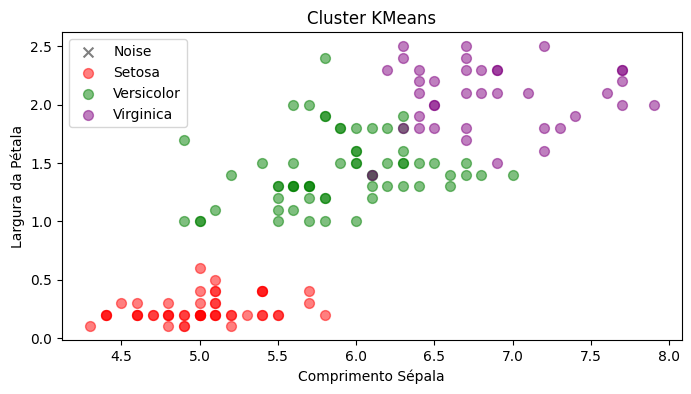

In [ ]:
kmeans = KMeans(n_clusters=3,n_init='auto')
kmeans.fit(iris.data)
print(kmeans.labels_)

resultados = confusion_matrix(iris.target, kmeans.labels_)
print(resultados)

plot_clusters(iris.data, kmeans.labels_, 'Cluster KMeans')

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  2  1  1  2  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  2  1  1
  1  1  2  1  1  1  1  1  1  3 -1  1 -1 -1  1  1  1  1  1  1  1 -1  3  1
  1  1  3  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


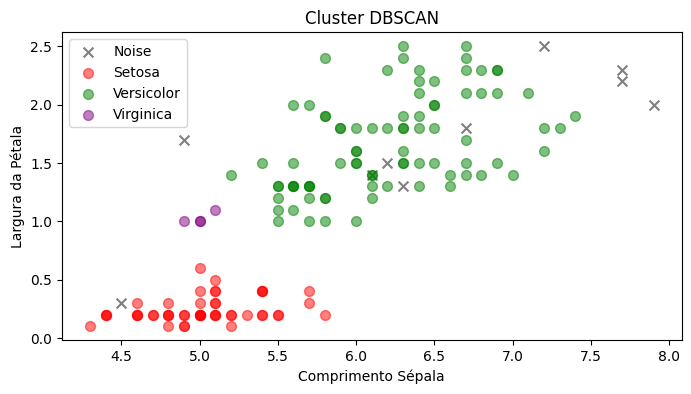

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=3)
dbscan_labels = dbscan.fit_predict(iris.data)
print(dbscan_labels)

plot_clusters(iris.data, dbscan_labels, 'Cluster DBSCAN')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
[[ 0 50  0]
 [49  0  1]
 [15  0 35]]


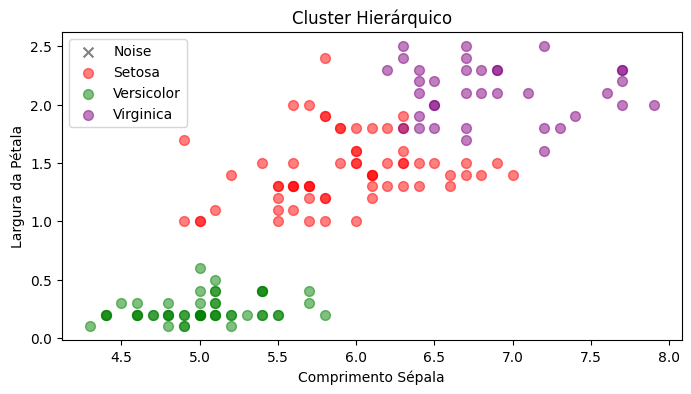

In [ ]:
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(iris.data)
print(agglo_labels)

resultados = confusion_matrix(iris.target, agglo_labels)
print(resultados)

plot_clusters(iris.data, agglo_labels, 'Cluster Hierárquico')

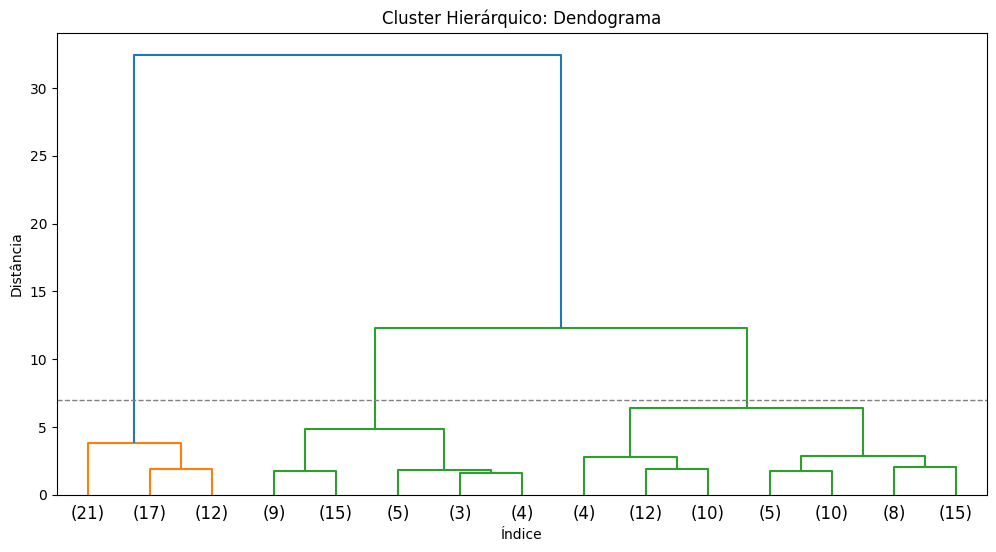

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Cluster Hierárquico: Dendograma")
plt.xlabel("Índice")
plt.ylabel("Distância")
linkage_matrix = linkage(iris.data, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=15)
plt.axhline(y=7, c='gray', lw=1, linestyle='dashed')
plt.show()

In [1]:
from sklearn import datasets
import numpy as np
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
from hopkins import *
from metric import *
from visual_assessment_of_tendency import *

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
iris = datasets.load_iris()
clust1 = scale(iris.data)
clust2 = scale(np.random.rand(150,4))

In [6]:
print(clust2)

[[ 1.45400482 -0.42459047 -0.32555464  1.41066234]
 [ 0.95154485 -0.95855529  0.93211315 -1.44699912]
 [ 0.12634431 -0.89731504  1.67620622  1.0659592 ]
 [ 0.15578851  0.37242803  1.04198308 -0.40091821]
 [ 1.00086836  0.72375331  0.35229763  0.25988661]
 [ 0.83984517  1.11038965  0.43303405 -0.82287385]
 [ 0.28119009  1.28691319 -0.1431091  -0.28092806]
 [ 1.05317019 -1.49884547  0.48306316 -0.31122688]
 [-0.21585514 -0.61543582  0.14852852  0.89873002]
 [-0.52854196  1.39593918  0.64340548 -0.12080703]
 [ 0.9675269   1.12178981 -0.1915837  -1.13330171]
 [-0.23203533  0.81887119 -0.70950093  0.15979286]
 [-1.61737154 -0.30892461 -0.43043331 -0.39678288]
 [-1.2482764  -0.66571521  0.2884865  -1.35865341]
 [-1.26832057  1.33454197 -1.30604197 -1.61783778]
 [-0.04779655  0.05570702 -0.48041399 -0.00954806]
 [ 0.83500917  0.1751332  -0.1558388   1.09000805]
 [-0.82511364 -1.54195944 -0.13663403 -0.36092743]
 [ 0.27111551  1.11469601 -0.32908192  1.57449602]
 [ 0.44981552 -1.3106397   1.52

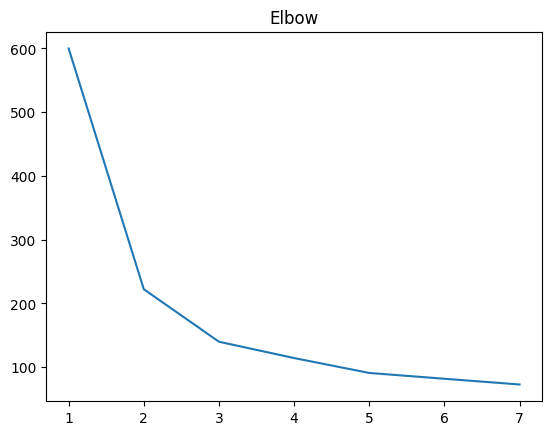

In [7]:
inertia = []
for i in range(1,8):
  kmeans = KMeans(n_clusters=i, n_init='auto')
  kmeans.fit(clust1)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title("Elbow")
plt.show()

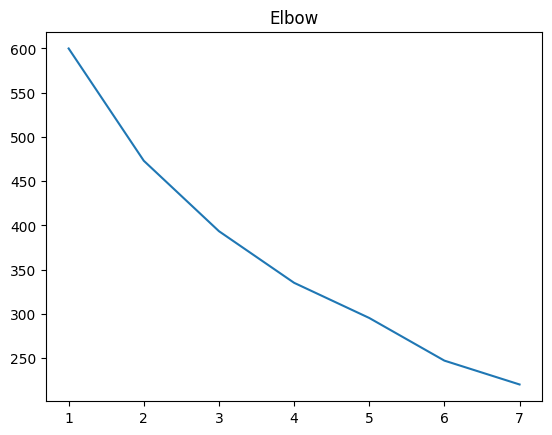

In [8]:
inertia = []
for i in range(1,8):
  kmeans = KMeans(n_clusters=i, n_init='auto')
  kmeans.fit(clust2)
  inertia.append(kmeans.inertia_)
plt.plot(range(1,8), inertia)
plt.title("Elbow")
plt.show()

In [13]:
hopkins(clust1, 150)

np.float64(0.17665145098421373)

In [14]:
hopkins(clust2, 150)

np.float64(0.494888787976984)

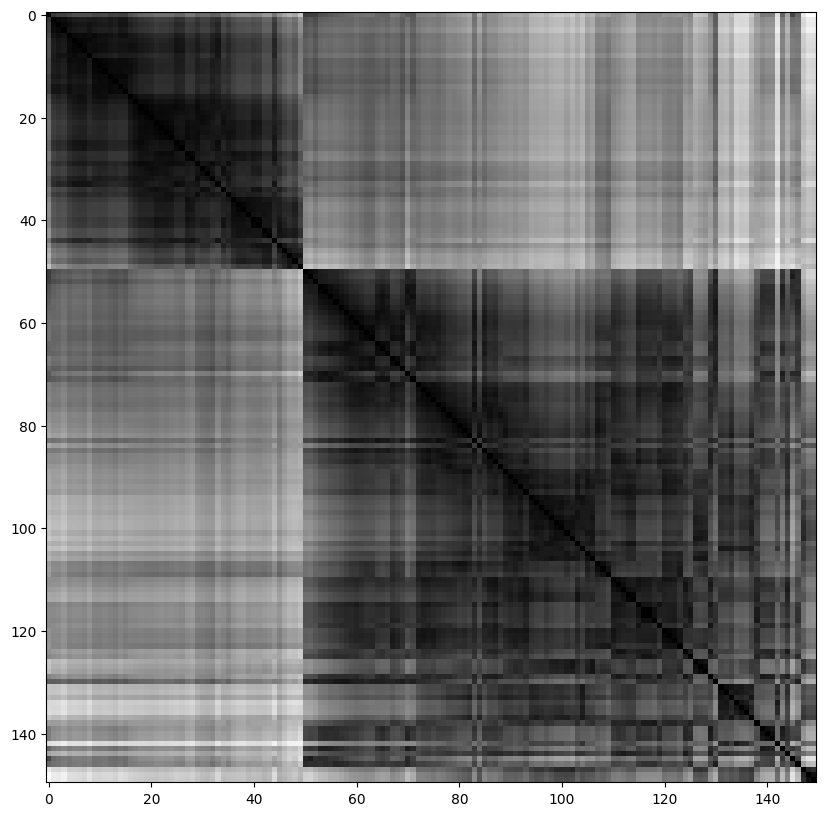

In [15]:
vat(clust1)

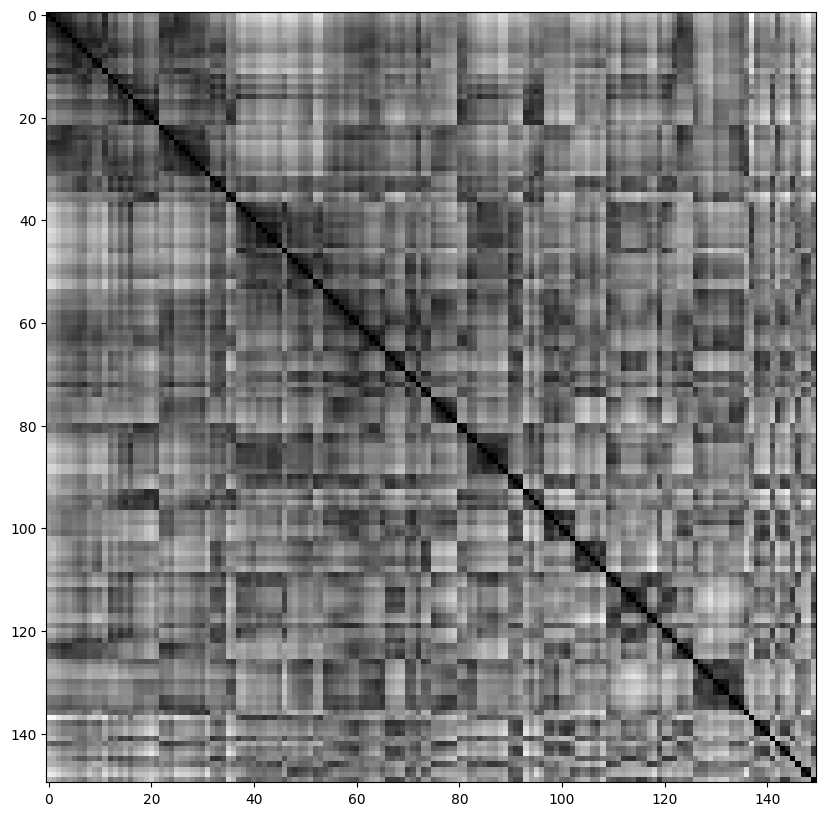

In [16]:
vat(clust2)

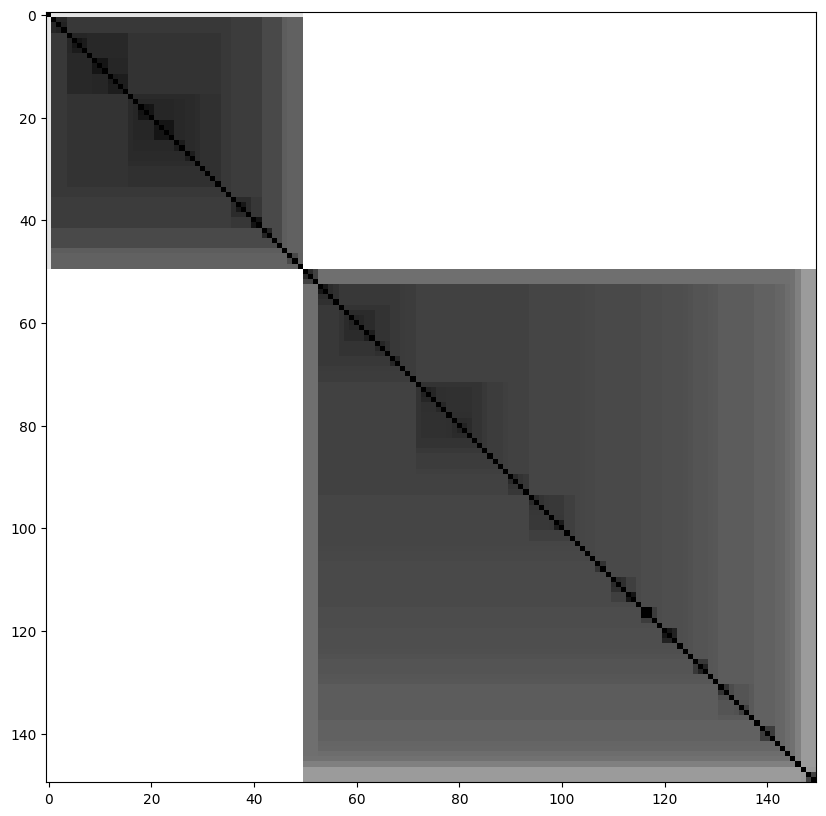

In [17]:
ivat(clust1)

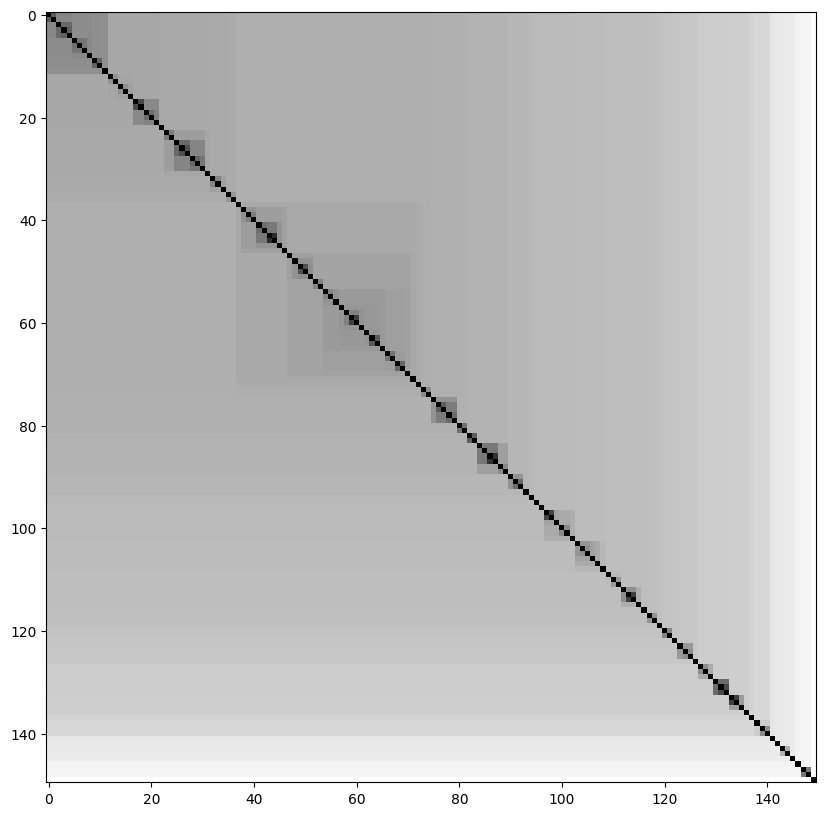

In [18]:
ivat(clust2)

In [26]:
#m = assess_tendency_by_metric(clust1, 'silhouette', 5)
#m = assess_tendency_by_metric(clust1, 'davies_bouldin', 5)
m = assess_tendency_by_metric(clust1, 'calinski_harabasz', 5)
print(m)

(np.int64(2), array([251.34933946, 241.9044017 , 207.26660627, 202.63665916]))


In [27]:
#m = assess_tendency_by_metric(clust2, 'silhouette', 5)
#m = assess_tendency_by_metric(clust2, 'davies_bouldin', 5)
m = assess_tendency_by_metric(clust2, 'calinski_harabasz', 5)
print(m)

(np.int64(5), array([39.36518676, 34.75976584, 40.4381376 , 41.34400845]))


In [28]:
m = assess_tendency_by_mean_metric_score(clust1, 5)
print(m)

2.0


In [30]:
m = assess_tendency_by_mean_metric_score(clust2, 5)
print(m)

4.0
